In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import random

In [5]:
import sys, os

In [6]:
sys.path.append(os.path.abspath(".."))

In [7]:
import equitytools_local.data as datatools

In [8]:
from importlib import reload
reload(datatools)

<module 'equitytools_local.data' from 'C:\\Users\\jonsw\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\Scripts\\equitytools_local\\data.py'>

In [9]:
import equitytools_local.modeling as modelingtools

In [10]:
reload(modelingtools)

<module 'equitytools_local.modeling' from 'C:\\Users\\jonsw\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\Scripts\\equitytools_local\\modeling.py'>

In [11]:
import equitytools_local.plotting as plottingtools

In [12]:
reload(plottingtools)

<module 'equitytools_local.plotting' from 'C:\\Users\\jonsw\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\Scripts\\equitytools_local\\plotting.py'>

In [13]:
from datetime import datetime

# This is the only input - tickers and quantity of each ticker owned

In [45]:
tickers_with_numbers_of_shares = [["NVDA", 200], ["AAPL", 200], ["MSFT", 500]]

In [46]:
tickers_with_numbers_of_shares2 = dict(tickers_with_numbers_of_shares)

# Now we process

In [47]:
tickers  = [row[0] for row in tickers_with_numbers_of_shares if row]  

In [48]:
print (tickers)

['NVDA', 'AAPL', 'MSFT']


In [49]:
import yfinance as yf

## Get the financial data for each ticker

In [50]:
map_of_tickerframes = {}

In [52]:
for ticker in tickers:
    map_of_tickerframes[ticker] = yf.download(ticker)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MSFT']: TypeError("'NoneType' object is not subscriptable")


## Now get the beta for each ticker

In [53]:
map_of_tickerbetas = {}

In [54]:
for ticker in tickers:
    stock = datatools.get_ticker_data(ticker)
    map_of_tickerbetas[ticker] = stock.info['beta']

In [55]:
print ( map_of_tickerbetas )

{'NVDA': 2.314, 'AAPL': 1.107, 'MSFT': 1.084}


## Now get the current prices for each ticker

In [56]:
map_of_tickerprices = {}

In [57]:
for ticker in tickers:
    stock = datatools.get_ticker_data(ticker)
    map_of_tickerprices[ticker] = stock.info['currentPrice']

In [58]:
print ( map_of_tickerprices )

{'NVDA': 189.82, 'AAPL': 264.58, 'MSFT': 397.23}


## Now get the initial stake for each ticker

In [59]:
map_of_tickerinitialstakes = {}

In [60]:
for ticker in tickers:
    stock = datatools.get_ticker_data(ticker)
    stake = tickers_with_numbers_of_shares2[ticker] * stock.info['currentPrice']
    map_of_tickerinitialstakes[ticker] = stake

In [61]:
print ( map_of_tickerinitialstakes )

{'NVDA': 37964.0, 'AAPL': 52916.0, 'MSFT': 198615.0}


## Now let's do 10 simulations over ten years each

In [62]:
num_year = 10
num_simuls = 10

In [63]:
current_simul = 0
current_year = 0

In [64]:
all_simuls = [[]]

In [65]:
val0 = 0

## Assuming S&P 500 average returns 10%, and sd of 16%

In [66]:
avg_market_rturn = 0.10

In [67]:
sd_market_return = 0.16

## Starting point for every simulation is val0

In [68]:
for ticker in tickers:
    val0 += map_of_tickerinitialstakes[ticker]

In [69]:
for index in range(1, 10): 
    simul = modelingtools.get_simlation(10, val0, avg_market_rturn, sd_market_return)
    all_simuls.append(simul)

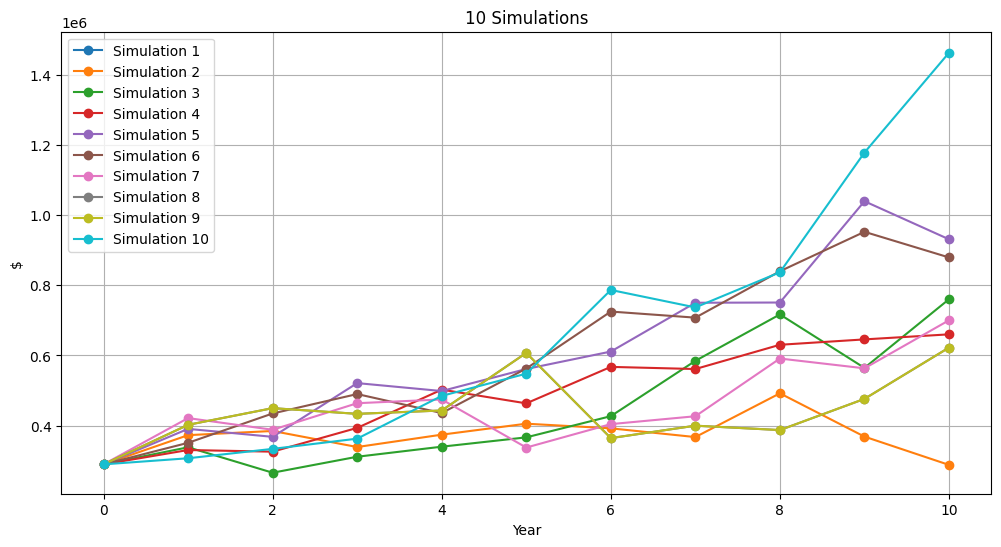

In [70]:
plottingtools.plot_simul_lines (all_simuls )